# Encoding Categorical Data
This notebook covers all major techniques for encoding categorical variables:
- Label Encoding
- One-Hot Encoding
- Ordinal Encoding
- Binary Encoding
- Frequency / Count Encoding
- Target Encoding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('categorical_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (30, 9)


,CustomerID,Gender,Education,City,MaritalStatus,ProductCategory,AgeGroup,SatisfactionRating,Purchased
0,1,Male,Bachelor's,New York,Single,Electronics,Young Adult,High,Yes
1,2,Female,Master's,Los Angeles,Married,Clothing,Adult,Medium,No
2,3,Male,PhD,Chicago,Divorced,Food,Senior,Low,Yes
3,4,Female,High School,Houston,Single,Electronics,Young Adult,High,Yes
4,5,Male,Bachelor's,Phoenix,Married,Clothing,Adult,Medium,No


In [2]:
# Quick overview of data types and categories
print('Data Types:')
print(df.dtypes)
print('\nCategorical Columns:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print('\nUnique values per column:')
for col in cat_cols:
    print(f'  {col}: {df[col].unique()}')

Data Types:
CustomerID            int64
Gender                  str
Education               str
City                    str
MaritalStatus           str
ProductCategory         str
AgeGroup                str
SatisfactionRating      str
Purchased               str
dtype: object

Categorical Columns:
['Gender', 'Education', 'City', 'MaritalStatus', 'ProductCategory', 'AgeGroup', 'SatisfactionRating', 'Purchased']

Unique values per column:
  Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
  Education: <StringArray>
['Bachelor's', 'Master's', 'PhD', 'High School']
Length: 4, dtype: str
  City: <StringArray>
[     'New York',   'Los Angeles',       'Chicago',       'Houston',
       'Phoenix',  'Philadelphia',   'San Antonio',     'San Diego',
        'Dallas',      'San Jose',        'Austin',  'Jacksonville',
    'Fort Worth',      'Columbus',     'Charlotte',  'Indianapolis',
 'San Francisco',       'Seattle',        'Denver',     'Nashville',
 'Oklahoma City',       'El 

## 1. Label Encoding
Converts each category to an integer (0, 1, 2, ...). Best for **binary** or **ordinal** columns. Not ideal for nominal data with many categories (implies order).

In [3]:
df_label = df.copy()
le = LabelEncoder()

# Apply to binary columns
for col in ['Gender', 'MaritalStatus', 'Purchased']:
    df_label[col + '_encoded'] = le.fit_transform(df_label[col])
    print(f'{col} mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_label[['Gender', 'Gender_encoded', 'MaritalStatus', 'MaritalStatus_encoded', 'Purchased', 'Purchased_encoded']].head(8)

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
MaritalStatus mapping: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}
Purchased mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


,Gender,Gender_encoded,MaritalStatus,MaritalStatus_encoded,Purchased,Purchased_encoded
0,Male,1,Single,2,Yes,1
1,Female,0,Married,1,No,0
2,Male,1,Divorced,0,Yes,1
3,Female,0,Single,2,Yes,1
4,Male,1,Married,1,No,0
5,Female,0,Single,2,Yes,1
6,Male,1,Married,1,No,0
7,Female,0,Divorced,0,Yes,1


## 2. One-Hot Encoding
Creates a new binary column for each category. Best for **nominal** data with no inherent order. Can cause dimensionality explosion with many categories.

In [4]:
df_ohe = df.copy()

# One-hot encode nominal columns
ohe_cols = ['ProductCategory', 'Gender', 'MaritalStatus']
df_ohe = pd.get_dummies(df_ohe, columns=ohe_cols, drop_first=False)

print('New columns after One-Hot Encoding:')
new_cols = [c for c in df_ohe.columns if any(c.startswith(p+'_') for p in ohe_cols)]
print(new_cols)
df_ohe[new_cols].head(8)

New columns after One-Hot Encoding:
['ProductCategory_Clothing', 'ProductCategory_Electronics', 'ProductCategory_Food', 'Gender_Female', 'Gender_Male', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Food,Gender_Female,Gender_Male,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,False,True,False,False,True,False,False,True
1,True,False,False,True,False,False,True,False
2,False,False,True,False,True,True,False,False
3,False,True,False,True,False,False,False,True
4,True,False,False,False,True,False,True,False
5,False,False,True,True,False,False,False,True
6,False,True,False,False,True,False,True,False
7,True,False,False,True,False,True,False,False


## 3. Ordinal Encoding
Assigns integers based on a **defined order**. Suitable for columns with a meaningful rank (e.g., Education level, Satisfaction rating).

In [5]:
df_ordinal = df.copy()
oe = OrdinalEncoder()

# Education: define logical order
edu_order = [['High School', "Bachelor's", "Master's", 'PhD']]
oe_edu = OrdinalEncoder(categories=edu_order)
df_ordinal['Education_encoded'] = oe_edu.fit_transform(df_ordinal[['Education']])

# SatisfactionRating: define order
sat_order = [['Low', 'Medium', 'High']]
oe_sat = OrdinalEncoder(categories=sat_order)
df_ordinal['SatisfactionRating_encoded'] = oe_sat.fit_transform(df_ordinal[['SatisfactionRating']])

# AgeGroup: define order
age_order = [['Young Adult', 'Adult', 'Senior']]
oe_age = OrdinalEncoder(categories=age_order)
df_ordinal['AgeGroup_encoded'] = oe_age.fit_transform(df_ordinal[['AgeGroup']])

df_ordinal[['Education', 'Education_encoded',
            'SatisfactionRating', 'SatisfactionRating_encoded',
            'AgeGroup', 'AgeGroup_encoded']].drop_duplicates().sort_values('Education_encoded')

,Education,Education_encoded,SatisfactionRating,SatisfactionRating_encoded,AgeGroup,AgeGroup_encoded
3,High School,0.0,High,2.0,Young Adult,0.0
6,High School,0.0,High,2.0,Senior,2.0
25,High School,0.0,Medium,1.0,Adult,1.0
11,High School,0.0,Low,0.0,Young Adult,0.0
15,Bachelor's,1.0,High,2.0,Senior,2.0
23,Bachelor's,1.0,Low,0.0,Young Adult,0.0
4,Bachelor's,1.0,Medium,1.0,Adult,1.0
0,Bachelor's,1.0,High,2.0,Young Adult,0.0
9,Master's,2.0,High,2.0,Senior,2.0
5,Master's,2.0,Low,0.0,Young Adult,0.0


## 4. Binary Encoding
Converts category to an integer, then to binary digits (bits), creating fewer columns than OHE. Useful for **high-cardinality** columns.

In [6]:
# Manual Binary Encoding for 'City'
df_binary = df.copy()

# Step 1: Assign integer to each city
city_map = {city: idx for idx, city in enumerate(df_binary['City'].unique())}
df_binary['City_int'] = df_binary['City'].map(city_map)

# Step 2: Convert integer to binary bits
n_bits = int(np.ceil(np.log2(len(city_map) + 1)))
for bit in range(n_bits):
    df_binary[f'City_bit{bit}'] = np.right_shift(df_binary['City_int'].astype(int), bit) & 1

binary_cols = ['City'] + [f'City_bit{b}' for b in range(n_bits)]
print(f'City encoded into {n_bits} bits (vs {len(city_map)} OHE columns)')
df_binary[binary_cols].drop_duplicates().head(10)

City encoded into 5 bits (vs 30 OHE columns)


,City,City_bit0,City_bit1,City_bit2,City_bit3,City_bit4
0,New York,0,0,0,0,0
1,Los Angeles,1,0,0,0,0
2,Chicago,0,1,0,0,0
3,Houston,1,1,0,0,0
4,Phoenix,0,0,1,0,0
5,Philadelphia,1,0,1,0,0
6,San Antonio,0,1,1,0,0
7,San Diego,1,1,1,0,0
8,Dallas,0,0,0,1,0
9,San Jose,1,0,0,1,0


## 5. Frequency / Count Encoding
Replaces each category with its **frequency** (proportion or count) in the dataset. Useful when frequency of a category is informative.

In [7]:
df_freq = df.copy()

for col in ['City', 'ProductCategory', 'Education']:
    freq_map = df_freq[col].value_counts(normalize=True)  # proportion
    df_freq[col + '_freq'] = df_freq[col].map(freq_map)
    print(f'{col} frequency mapping:')
    print(freq_map.to_dict())
    print()

df_freq[['City', 'City_freq', 'ProductCategory', 'ProductCategory_freq']].drop_duplicates().head(10)

City frequency mapping:
{'New York': 0.03333333333333333, 'Los Angeles': 0.03333333333333333, 'Chicago': 0.03333333333333333, 'Houston': 0.03333333333333333, 'Phoenix': 0.03333333333333333, 'Philadelphia': 0.03333333333333333, 'San Antonio': 0.03333333333333333, 'San Diego': 0.03333333333333333, 'Dallas': 0.03333333333333333, 'San Jose': 0.03333333333333333, 'Austin': 0.03333333333333333, 'Jacksonville': 0.03333333333333333, 'Fort Worth': 0.03333333333333333, 'Columbus': 0.03333333333333333, 'Charlotte': 0.03333333333333333, 'Indianapolis': 0.03333333333333333, 'San Francisco': 0.03333333333333333, 'Seattle': 0.03333333333333333, 'Denver': 0.03333333333333333, 'Nashville': 0.03333333333333333, 'Oklahoma City': 0.03333333333333333, 'El Paso': 0.03333333333333333, 'Boston': 0.03333333333333333, 'Portland': 0.03333333333333333, 'Las Vegas': 0.03333333333333333, 'Memphis': 0.03333333333333333, 'Louisville': 0.03333333333333333, 'Baltimore': 0.03333333333333333, 'Milwaukee': 0.0333333333333

,City,City_freq,ProductCategory,ProductCategory_freq
0,New York,0.033333,Electronics,0.333333
1,Los Angeles,0.033333,Clothing,0.333333
2,Chicago,0.033333,Food,0.333333
3,Houston,0.033333,Electronics,0.333333
4,Phoenix,0.033333,Clothing,0.333333
5,Philadelphia,0.033333,Food,0.333333
6,San Antonio,0.033333,Electronics,0.333333
7,San Diego,0.033333,Clothing,0.333333
8,Dallas,0.033333,Food,0.333333
9,San Jose,0.033333,Electronics,0.333333


## 6. Target Encoding (Mean Encoding)
Replaces each category with the **mean of the target variable** for that category. Powerful for high-cardinality features, but prone to overfitting — use with cross-validation in practice.

In [8]:
df_target = df.copy()

# Encode target first
df_target['Purchased_bin'] = (df_target['Purchased'] == 'Yes').astype(int)

# Target encode categorical columns
for col in ['City', 'ProductCategory', 'Education', 'AgeGroup']:
    target_map = df_target.groupby(col)['Purchased_bin'].mean()
    df_target[col + '_target_enc'] = df_target[col].map(target_map)
    print(f'{col} → target encoded mean:')
    print(target_map.to_dict())
    print()

df_target[['ProductCategory', 'ProductCategory_target_enc', 'Purchased']].drop_duplicates()

City → target encoded mean:
{'Albuquerque': 1.0, 'Austin': 1.0, 'Baltimore': 1.0, 'Boston': 1.0, 'Charlotte': 1.0, 'Chicago': 1.0, 'Columbus': 0.0, 'Dallas': 0.0, 'Denver': 0.0, 'El Paso': 0.0, 'Fort Worth': 1.0, 'Houston': 1.0, 'Indianapolis': 1.0, 'Jacksonville': 0.0, 'Las Vegas': 1.0, 'Los Angeles': 0.0, 'Louisville': 0.0, 'Memphis': 1.0, 'Milwaukee': 0.0, 'Nashville': 1.0, 'New York': 1.0, 'Oklahoma City': 1.0, 'Philadelphia': 1.0, 'Phoenix': 0.0, 'Portland': 0.0, 'San Antonio': 0.0, 'San Diego': 1.0, 'San Francisco': 0.0, 'San Jose': 1.0, 'Seattle': 1.0}

ProductCategory → target encoded mean:
{'Clothing': 0.5, 'Electronics': 0.7, 'Food': 0.6}

Education → target encoded mean:
{"Bachelor's": 0.625, 'High School': 0.5, "Master's": 0.625, 'PhD': 0.6666666666666666}

AgeGroup → target encoded mean:
{'Adult': 0.5, 'Senior': 0.6666666666666666, 'Young Adult': 0.6363636363636364}



,ProductCategory,ProductCategory_target_enc,Purchased
0,Electronics,0.7,Yes
1,Clothing,0.5,No
2,Food,0.6,Yes
6,Electronics,0.7,No
7,Clothing,0.5,Yes
8,Food,0.6,No


## 7. Comparison Summary
Visual comparison of encoded feature counts per technique.

In [9]:
# Summary table
summary = pd.DataFrame({
    'Technique': ['Label Encoding', 'One-Hot Encoding', 'Ordinal Encoding', 
                  'Binary Encoding', 'Frequency Encoding', 'Target Encoding'],
    'Best For': ['Binary/Ordinal', 'Nominal (low cardinality)', 'Ordered categories',
                 'High cardinality', 'High cardinality', 'High cardinality'],
    'Preserves Order': ['No (arbitrary)', 'No', 'Yes', 'No', 'No', 'No'],
    'New Columns': ['None (in-place)', 'One per category', 'None (in-place)',
                    'log2(n) bits', 'None (in-place)', 'None (in-place)'],
    'Risk': ['Implies order', 'Dimensionality', 'Requires known order',
              'Information loss', 'Collision', 'Overfitting']
})
summary

,Technique,Best For,Preserves Order,New Columns,Risk
0,Label Encoding,Binary/Ordinal,No (arbitrary),None (in-place),Implies order
1,One-Hot Encoding,Nominal (low cardinality),No,One per category,Dimensionality
2,Ordinal Encoding,Ordered categories,Yes,None (in-place),Requires known order
3,Binary Encoding,High cardinality,No,log2(n) bits,Information loss
4,Frequency Encoding,High cardinality,No,None (in-place),Collision
5,Target Encoding,High cardinality,No,None (in-place),Overfitting


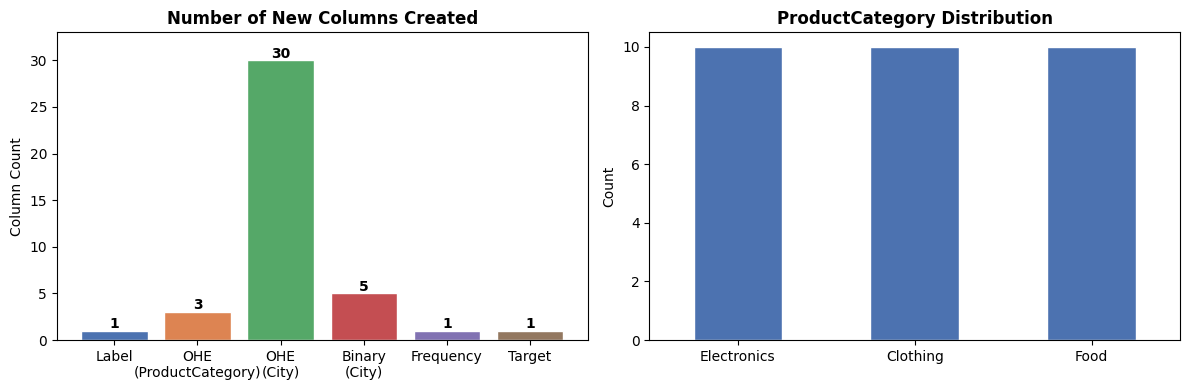

In [10]:
# Visualize: OHE column count vs Binary for 'City'
n_cities = df['City'].nunique()
n_binary = int(np.ceil(np.log2(n_cities + 1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: columns generated
techniques = ['Label', 'OHE\n(ProductCategory)', 'OHE\n(City)', 'Binary\n(City)', 'Frequency', 'Target']
col_counts = [1, df['ProductCategory'].nunique(), n_cities, n_binary, 1, 1]
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
axes[0].bar(techniques, col_counts, color=colors, edgecolor='white')
axes[0].set_title('Number of New Columns Created', fontweight='bold')
axes[0].set_ylabel('Column Count')
axes[0].set_ylim(0, max(col_counts) + 3)
for i, v in enumerate(col_counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Distribution of ProductCategory
df['ProductCategory'].value_counts().plot(kind='bar', ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('ProductCategory Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 8. Final Encoded Dataset (All Techniques Combined)
Building a clean, ML-ready dataframe using best-fit encoding per column.

In [11]:
df_final = df.copy()

# Label Encode binary columns
le = LabelEncoder()
df_final['Gender'] = le.fit_transform(df_final['Gender'])
df_final['Purchased'] = (df_final['Purchased'] == 'Yes').astype(int)
df_final['MaritalStatus'] = le.fit_transform(df_final['MaritalStatus'])

# Ordinal Encode ordered columns
edu_oe = OrdinalEncoder(categories=[['High School', "Bachelor's", "Master's", 'PhD']])
df_final['Education'] = edu_oe.fit_transform(df_final[['Education']])

sat_oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df_final['SatisfactionRating'] = sat_oe.fit_transform(df_final[['SatisfactionRating']])

age_oe = OrdinalEncoder(categories=[['Young Adult', 'Adult', 'Senior']])
df_final['AgeGroup'] = age_oe.fit_transform(df_final[['AgeGroup']])

# One-Hot Encode nominal column
df_final = pd.get_dummies(df_final, columns=['ProductCategory'], drop_first=False)

# Frequency Encode high-cardinality City
city_freq = df['City'].value_counts(normalize=True)
df_final['City'] = df['City'].map(city_freq)

print('Final ML-ready dataframe shape:', df_final.shape)
print('Columns:', df_final.columns.tolist())
df_final.head()

Final ML-ready dataframe shape: (30, 11)
Columns: ['CustomerID', 'Gender', 'Education', 'City', 'MaritalStatus', 'AgeGroup', 'SatisfactionRating', 'Purchased', 'ProductCategory_Clothing', 'ProductCategory_Electronics', 'ProductCategory_Food']


,CustomerID,Gender,Education,City,MaritalStatus,AgeGroup,SatisfactionRating,Purchased,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Food
0,1,1,1.0,0.033333,2,0.0,2.0,1,False,True,False
1,2,0,2.0,0.033333,1,1.0,1.0,0,True,False,False
2,3,1,3.0,0.033333,0,2.0,0.0,1,False,False,True
3,4,0,0.0,0.033333,2,0.0,2.0,1,False,True,False
4,5,1,1.0,0.033333,1,1.0,1.0,0,True,False,False
